# Circuit Distribution and Basic Usage

`pytket-dqc` is a python package for the distribution of quantum circuits between interconnected quantum computers, which we call modules (or servers). Here we gather some basic usage of `pytket-dqc`, and introduce some basic concepts from distributed quantum computing (DQC). For more extensive discussion on `pytket-dqc` please see the documentation [here](https://cqcl.github.io/pytket-dqc/).

The main data structures we will discuss include: `NISQNetwork`, the network on which a circuit will be distributed; `Circuit`, describing the circuit to be distributed; `Distribution`, which describes the distribution of a circuit onto a network; and `Distributor`, the parent class for a collection of techniques for generating a `Distribution`. We will also introduce the notions of starting and ending processes, link qubits, detached gates and Steiner trees, as discussed in greater detail in the corresponding paper [Distributing circuits over heterogeneous, modular quantum computing network architectures](https://arxiv.org/abs/2305.14148).

## Networks

Networks of quantum servers are specified by two properties:
- The server coupling, detailing which servers are connected to which others. In `pytket-dqc` this is specified by a list of pairs of integers, where each pair signifies that there is a connection between those two servers. 
- The qubits each server contains. This is specified by a dictionary from the server to a list of qubits it contains. 

An example is given below, where blue lines indicate connections between modules, and red lines indicate connections between qubits within modules. The vertex labels are the indexes of the qubits.

In [1]:
from pytket_dqc.networks import NISQNetwork

network = NISQNetwork(
    [[0, 1], [0, 2], [0, 3]],
    {0: [0, 1, 2, 3], 1: [4, 5, 6], 2: [7, 8, 9, 10, 11], 3: [12, 13]},
)
f = network.draw_nisq_network()

/opt/anaconda3/envs/cisco/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/opt/anaconda3/envs/cisco/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/opt/anaconda3/envs/cisco/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/opt/anaconda3/envs/cisco/lib/python3.12/site-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /opt/anaconda3/envs/cisco/lib/python3.12/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /opt/anaconda3/env

ImportError: requires pygraphviz http://pygraphviz.github.io/

<Figure size 800x800 with 0 Axes>

## Circuits

Note that the accepted gate set for `pytket-dqc` is CU1, Rz, and H. While restrictive, this is a universal gate set, and `pytket-dqc` includes some handy utilities for rebasing your circuit if it is not in the correct gate set initially.

In [3]:
from pytket_dqc.utils import DQCPass
from pytket.circuit.display import render_circuit_jupyter
from pytket import Circuit

circ = Circuit(4).CY(0, 1).CZ(1, 2).H(1).X(3).CX(1, 0).CZ(1, 3)
render_circuit_jupyter(circ)

DQCPass().apply(circ)
render_circuit_jupyter(circ)

## Distributors and Distributions

`pytket-dqc` includes several instances of the `Distributor` class, each of which convert a `Circuit` and a `NISQNetwork` into a `Distribution`. A `Distribution` describes how and where gates should be acted in the network, and where qubits of the original circuit should be assigned. To demonstrate this let us first introduce a small network and circuit.

In [4]:
from pytket import OpType

circ = Circuit(2)
circ.add_gate(OpType.CU1, 1.0, [0, 1]).H(0).Rz(0.3, 0).H(0).add_gate(
    OpType.CU1, 1.0, [0, 1]
)
render_circuit_jupyter(circ)

network = NISQNetwork([[0, 1], [0, 2]], {0: [0], 1: [1], 2: [2]})
f = network.draw_nisq_network()

NameError: name 'NISQNetwork' is not defined

One example of an available `Distributor` is `PartitioningAnnealing`, which uses simulated annealing to distribute a circuit to a network. Other distributors are discussed further in the notebook `distributor_comparison`. The resulting `Distribution` includes several useful methods, including the generation of a `pytket` `Circuit` which includes the operations required to implement it in a distributed way, as is demonstrated below.

In [ ]:
from pytket_dqc.distributors import PartitioningAnnealing

distribution = PartitioningAnnealing().distribute(circ, network, seed=50)

distributed_circ = distribution.to_pytket_circuit()
render_circuit_jupyter(distributed_circ)

print("Distributed Circuit Commands:", *distributed_circ.get_commands(), sep="\n")

Distributed Circuit Commands:
starting_process server_0[0], server_2_link_register[0];
CU1(1) server_2_link_register[0], server_2[0];
H server_2[0];
Rz(0.3) server_2[0];
H server_2[0];
CU1(1) server_2_link_register[0], server_2[0];
ending_process server_2_link_register[0], server_0[0];


Here we see that the qubits in the original circuit have been assigned to particular modules in the network, that two instances of `CustomGate` have been added to the circuit, and that an additional ancilla has been added to the circuit. The first and second `CustomGate` are a starting processes and ending process respectively, as seen in the corresponding list of commands. These together implement the single EJPP process required to distribute the two 2-qubit gates in the circuit. Please see [Optimal local implementation of non-local quantum gates](https://arxiv.org/abs/quant-ph/0005101) for further details on the EJPP protocol itself.

## Remote Gates 

As well as facilitating the automatic generation of a `Distribution`, `pytket-dqc` allows for a custom `Distribution` to be defined. This requires, in addition to a `NISQNetwork` as discussed above, a `HypergraphCircuit`, which manages some additional information about a `pytket` `Circuit`, and a `Placement`, which describes where gates and qubits are assigned. The placement below assigns the two qubits in the circuit to the modules at the ends of the line network, and assigns the two gates to the central module.

In [ ]:
from pytket_dqc.placement import Placement
from pytket_dqc import Distribution
from pytket_dqc.circuits import HypergraphCircuit

hyp_circ = HypergraphCircuit(circ)
placement = Placement({0: 1, 1: 2, 2: 0, 3: 0})
distribution = Distribution(hyp_circ, placement, network)
assert distribution.is_valid()

circ_with_dist = distribution.to_pytket_circuit()
render_circuit_jupyter(circ_with_dist)
print("Distributed Circuit Commands:", *circ_with_dist.get_commands(), sep="\n")

Distributed Circuit Commands:
starting_process server_1[0], server_0_link_register[0];
starting_process server_2[0], server_0_link_register[1];
CU1(1) server_0_link_register[1], server_0_link_register[0];
ending_process server_0_link_register[0], server_1[0];
H server_1[0];
Rz(0.3) server_1[0];
H server_1[0];
starting_process server_1[0], server_0_link_register[0];
CU1(1) server_0_link_register[1], server_0_link_register[0];
ending_process server_0_link_register[0], server_1[0];
ending_process server_0_link_register[1], server_2[0];


Notice that ancilla qubits are added to the central module to hold the required ebits. Moreover, we see that the gates are acted on a different server from the servers where the qubits are placed. As such in this case we have one server which consists of only link qubits. Gates acting between link qubits only are referred to as 'detached' gates.

## Entanglement Distribution

When implementing starting and ending processes `pytket-dqc` will make some effort to use the minimum number of distribution operations required to implement a sequence of gates remotely, given a `Placement`. Consider for example the following three pronged star network.

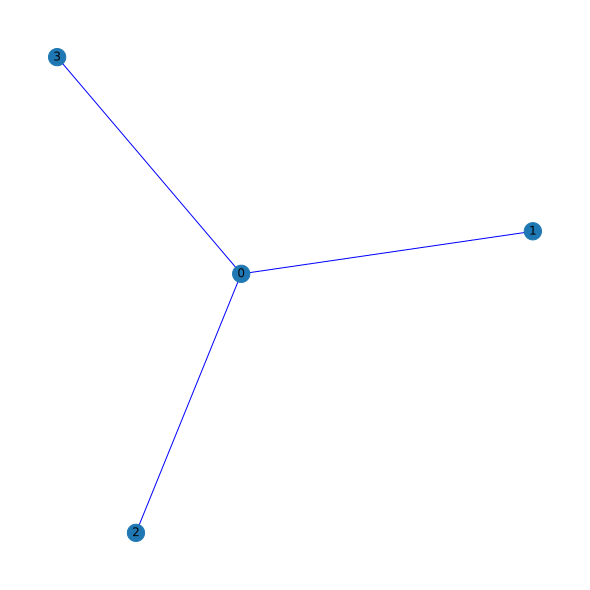

In [ ]:
network = NISQNetwork([[0, 1], [0, 2], [0, 3]], {0: [0], 1: [1], 2: [2], 3: [3]})
f = network.draw_nisq_network()

and the following simple three qubit circuit.

In [ ]:
circ = Circuit(3)
circ.add_gate(OpType.CU1, 1.0, [0, 1]).add_gate(OpType.CU1, 1.0, [0, 2])
render_circuit_jupyter(circ)

Imagine the qubits of this circuit are placed on the prongs of this network, and that the gates are placed on the modules which hold their target. Then the minimal way to distribute these gates is to create an entangled copy of the information contained in the control qubit with the central module, and then repeat from there to the two other edge modules. `pytket-dqc` will take this approach, as seen here.

In [ ]:
placement = Placement({0: 1, 1: 2, 2: 3, 3: 2, 4: 3})
distribution = Distribution(HypergraphCircuit(circ), placement, network)
assert distribution.is_valid()

circ_with_dist = distribution.to_pytket_circuit()
render_circuit_jupyter(circ_with_dist)

: 

More formally, `pytket-dqc` will consume ebits along the edges of the [Steiner tree](https://en.wikipedia.org/wiki/Steiner_tree_problem) which connects the modules containing the qubits acted on by the sequence of gates.

An additional technique we will use is embedding, which in particular is utilised by the `CoverEmbedding` `Distributor`. In some cases, embedding allows ebits to survive past Hadamard gates, allowing for their reuse. Consider the below example of the SWAP gate, which can be decomposed as a sequence of CZ gates sandwiched by Hadamard gates. Without embedding each of the 3 CZ gates would require an ebit to be distributed on the simple 2 module network given below. However, the central CZ can be embedded, and the ebit required to implement the first CZ gate remotely can be reused by the third, assuming a correction is made on the embedded portion of the circuit. Further technical details on embedding can be found in [Entanglement-efficient bipartite-distributed quantum computing with entanglement-assisted packing processes](https://arxiv.org/abs/2212.12688)

In [ ]:
from pytket_dqc.distributors import CoverEmbedding

network = NISQNetwork([[0, 1]], {0: [0], 1: [1]})

circ = Circuit(2).SWAP(0, 1)
DQCPass().apply(circ)
render_circuit_jupyter(circ)

distribution = CoverEmbedding().distribute(circ, network, seed=0)
circ_with_dist = distribution.to_pytket_circuit()
render_circuit_jupyter(circ_with_dist)

In [ ]:
from pytket.qasm import circuit_from_qasm_str
# from pytket.extensions.qiskit import AerBackend
from pytket import Circuit, OpType
from pytket_dqc.placement import Placement
from pytket_dqc import Distribution
from pytket_dqc.circuits import HypergraphCircuit
from pytket_dqc.networks import NISQNetwork
from pytket.qasm import circuit_from_qasm_str
from pytket_dqc.utils import DQCPass
from pytket_dqc.distributors import PartitioningAnnealing
from pytket.circuit.display import render_circuit_jupyter
qasm_string = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[4];
creg m[4];

// Initialization
h q[0]; h q[1]; h q[2]; h q[3];

// Grover Iteration 1
x q[2];
h q[3]; ccx q[0], q[1], q[2]; h q[3];
x q[2];
h q; x q;
h q[3]; c3x q[0], q[1], q[2], q[3]; h q[3];
x q; h q;

// Grover Iteration 2
x q[2];
h q[3]; c3x q[0], q[1], q[2], q[3]; h q[3];
x q[2];
h q; x q;
h q[3]; c3x q[0], q[1], q[2], q[3]; h q[3];
x q; h q;

"""

circ = circuit_from_qasm_str(qasm_string)
network = NISQNetwork([[0, 1], [0, 2]], {0: [0, 1], 1: [2], 2: [3]})
DQCPass().apply(circ)
distribution = PartitioningAnnealing().distribute(circ, network)
assert distribution.is_valid()
dist_circ = distribution.to_pytket_circuit()
print(dist_circ)
render_circuit_jupyter(dist_circ)
print("Distributed Circuit Commands:", *dist_circ.get_commands(), sep="\n")

<tket::Circuit, qubits=8, gates=251>


Distributed Circuit Commands:
H server_0[0];
H server_0[1];
Rz(2.875) server_1[0];
H server_2[0];
Rz(3.25) server_0[0];
Rz(1) server_0[1];
H server_1[0];
Rz(1.25) server_2[0];
CU1(1) server_0[1], server_0[0];
starting_process server_2[0], server_0_link_register[0];
H server_0[1];
Rz(2.25) server_0[1];
H server_0[1];
CU1(1) server_0[1], server_0_link_register[0];
H server_0[1];
Rz(1.75) server_0[1];
H server_0[1];
CU1(1) server_0[1], server_0[0];
H server_0[0];
H server_0[1];
Rz(3) server_0[0];
Rz(2.25) server_0[1];
H server_0[1];
Rz(1) server_0[1];
CU1(1) server_0[1], server_0_link_register[0];
CU1(1) server_0[0], server_0_link_register[0];
H server_0[1];
H server_0[0];
Rz(1.125) server_0[1];
Rz(2.25) server_0[0];
H server_0[1];
H server_0[0];
Rz(2.125) server_0[0];
CU1(1) server_0[0], server_0_link_register[0];
H server_0[0];
ending_process server_0_link_register[0], server_2[0];
Rz(1) server_0[0];
H server_2[0];
Rz(2.125) server_2[0];
starting_process server_2[0], server_0_link_regis

In [5]:
from pytket.qasm import circuit_from_qasm_str
# from pytket.extensions.qiskit import AerBackend
from pytket import Circuit, OpType
from pytket_dqc.placement import Placement
from pytket_dqc import Distribution
from pytket_dqc.circuits import HypergraphCircuit
from pytket_dqc.networks import NISQNetwork
from pytket.qasm import circuit_from_qasm_str
from pytket_dqc.utils import DQCPass
from pytket_dqc.distributors import PartitioningAnnealing
from pytket.circuit.display import render_circuit_jupyter
from pytket.qasm import circuit_from_qasm
qasm_string = """
OPENQASM 2.0;
include "qelib1.inc";

// Declare 18 qubits for Grover's search
qreg q[18];
// Declare 16 ancilla qubits for decomposing 17-controlled X
qreg anc[16];
// Classical register to store measurements
creg c[18];

// --- Initialization: apply H to all qubits ---
h q[0]; h q[1]; h q[2]; h q[3]; h q[4]; h q[5]; h q[6]; h q[7]; 
h q[8]; h q[9]; h q[10]; h q[11]; h q[12]; h q[13]; h q[14]; h q[15]; h q[16]; h q[17];

// --- Apply X gates for oracle to match target 10111... ---
// Flip qubits that should be 0 in the target
x q[1]; // second qubit is 0

// --- Oracle decomposition using CCX ladder ---
// Level 1 CCX
ccx q[0], q[1], anc[0];
ccx q[2], q[3], anc[1];
ccx q[4], q[5], anc[2];
ccx q[6], q[7], anc[3];
ccx q[8], q[9], anc[4];
ccx q[10], q[11], anc[5];
ccx q[12], q[13], anc[6];
ccx q[14], q[15], anc[7];

// Level 2 CCX
ccx anc[0], anc[1], anc[8];
ccx anc[2], anc[3], anc[9];
ccx anc[4], anc[5], anc[10];
ccx anc[6], anc[7], anc[11];

// Level 3 CCX
ccx anc[8], anc[9], anc[12];
ccx anc[10], anc[11], anc[13];

// Level 4 CCX
ccx anc[12], anc[13], anc[14];

// Final CCX to apply target flip on last qubit
ccx anc[14], q[16], q[17];  // q[17] is the output qubit flipped if all controls are 1

// --- Uncompute the ancilla to reset them ---
ccx anc[12], anc[13], anc[14];
ccx anc[10], anc[11], anc[13];
ccx anc[8], anc[9], anc[12];
ccx anc[0], anc[1], anc[8];
ccx anc[2], anc[3], anc[9];
ccx anc[4], anc[5], anc[10];
ccx anc[6], anc[7], anc[11];
ccx q[0], q[1], anc[0];
ccx q[2], q[3], anc[1];
ccx q[4], q[5], anc[2];
ccx q[6], q[7], anc[3];
ccx q[8], q[9], anc[4];
ccx q[10], q[11], anc[5];
ccx q[12], q[13], anc[6];
ccx q[14], q[15], anc[7];

// --- Grover diffusion operator ---
// Apply H, X, multi-controlled Z (similar CCX ladder), then H, X again
// (You can construct similarly if you want full Grover iteration)

// --- Measure all qubits ---
measure q[0] -> c[0]; measure q[1] -> c[1]; measure q[2] -> c[2]; measure q[3] -> c[3];
measure q[4] -> c[4]; measure q[5] -> c[5]; measure q[6] -> c[6]; measure q[7] -> c[7];
measure q[8] -> c[8]; measure q[9] -> c[9]; measure q[10] -> c[10]; measure q[11] -> c[11];
measure q[12] -> c[12]; measure q[13] -> c[13]; measure q[14] -> c[14]; measure q[15] -> c[15];
measure q[16] -> c[16]; measure q[17] -> c[17];

"""
circ = circuit_from_qasm("qasm/grover_9q_no_ancilla.qasm")
# circ = circuit_from_qasm_str(qasm_string)
# network = NISQNetwork([[0, 1], [0, 2]], {0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 1: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], 2: [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]})
# network = NISQNetwork([[0]], {0: [0, 1, 2, 3, 4]})
network = NISQNetwork(
    [[0, 1]],
    {
        0: list(range(0, 18)),   # 18 qubits
        1: list(range(18, 36))   # 18 qubits
    }
)
DQCPass().apply(circ)
distribution = PartitioningAnnealing().distribute(circ, network)
assert distribution.is_valid()
dist_circ = distribution.to_pytket_circuit()
print(dist_circ)
render_circuit_jupyter(dist_circ)
commands = dist_circ.get_commands()
with open("grover_9_2qpu.txt", "w") as f:
    f.write(f"Distributed Circuit: {dist_circ}\n")
    f.write(f"Total commands: {len(commands)}\n")
    f.write("=" * 60 + "\n\n")
    for i, cmd in enumerate(commands):
        f.write(f"{i}: {cmd}\n")

print(f"\n✅ Saved {len(commands)} commands")
print("Distributed Circuit Commands:", *dist_circ.get_commands(), sep="\n")

<tket::Circuit, qubits=17, gates=41968>



✅ Saved 41968 commands
Distributed Circuit Commands:
H server_0[0];
H server_0[1];
Rz(1.125) server_0[2];
H server_0[3];
H server_1[0];
Rz(3) server_1[1];
H server_1[2];
H server_1[3];
Rz(2.5) server_1[4];
Rz(1) server_0[0];
Rz(1.125) server_0[1];
H server_0[2];
Rz(3.375) server_0[3];
Rz(1.75391) server_1[0];
H server_1[1];
Rz(1.125) server_1[2];
Rz(1.125) server_1[3];
H server_1[4];
H server_0[1];
Rz(1) server_0[2];
starting_process server_0[3], server_1_link_register[0];
starting_process server_1[0], server_0_link_register[2];
Rz(3.125) server_1[1];
H server_1[3];
Rz(1) server_1[4];
Rz(3) server_0[1];
starting_process server_1[1], server_0_link_register[1];
Rz(3) server_1[3];
H server_1[4];
CU1(1) server_1_link_register[0], server_1[3];
Rz(3.5) server_1[4];
H server_1[3];
Rz(2.125) server_1[3];
H server_1[3];
Rz(1) server_1[3];
CU1(1) server_1_link_register[0], server_1[3];
H server_1[3];
Rz(0.25) server_1[3];
starting_process server_1[3], server_0_link_register[0];
CU1(1) server_0[

## QAOA 

In [4]:
from pytket.qasm import circuit_from_qasm_str
# from pytket.extensions.qiskit import AerBackend
from pytket import Circuit, OpType
from pytket_dqc.placement import Placement
from pytket_dqc import Distribution
from pytket_dqc.circuits import HypergraphCircuit
from pytket_dqc.networks import NISQNetwork
from pytket.qasm import circuit_from_qasm_str
from pytket_dqc.utils import DQCPass
from pytket_dqc.distributors import PartitioningAnnealing
from pytket.circuit.display import render_circuit_jupyter
import itertools

def generate_qaoa_qasm(n_qubits, edges, gammas, betas):

    if len(gammas) != len(betas):
        raise ValueError("gammas and betas must match")

    p = len(gammas)

    lines = [
        'OPENQASM 2.0;',
        'include "qelib1.inc";',
        f'qreg q[{n_qubits}];',
        f'creg c[{n_qubits}];'
    ]

    # ── Initial state ──
    lines.append('// Initial state')
    for i in range(n_qubits):
        lines.append(f'h q[{i}];')

    # ── QAOA layers ──
    for layer in range(p):
        gamma = gammas[layer]
        beta = betas[layer]

        lines.append(f'\n// --- Layer {layer+1} ---')

        # ── COST HAMILTONIAN ──
        lines.append('// Cost Hamiltonian (MaxCut ZZ)')
        for i, j in edges:
            lines.append(f'cx q[{i}], q[{j}];')
            lines.append(f'rz({-gamma}) q[{j}];')       # ✅ -gamma
            lines.append(f'cx q[{i}], q[{j}];')

        # ── MIXER ──
        lines.append('// Mixer Hamiltonian')
        for i in range(n_qubits):
            lines.append(f'rx({2 * beta}) q[{i}];')

    # ── Measurement ──
    # lines.append('\n// Measurement')
    # for i in range(n_qubits):
    #     lines.append(f'measure q[{i}] -> c[{i}];')

    return "\n".join(lines)


# ─────────────────────────────────────────────
# 2. MAXCUT COST FUNCTION
# ─────────────────────────────────────────────
def maxcut_value(bitstring, edges):
    return sum(1 for i, j in edges if bitstring[i] != bitstring[j])


# ─────────────────────────────────────────────
# 3. BRUTE FORCE OPTIMUM
# ─────────────────────────────────────────────
def brute_force_maxcut(n_qubits, edges):
    best_cost = -1
    best_states = []

    for bits in itertools.product('01', repeat=n_qubits):
        b = ''.join(bits)
        c = maxcut_value(b, edges)

        if c > best_cost:
            best_cost = c
            best_states = [b]
        elif c == best_cost:
            best_states.append(b)

    return best_cost, best_states


# ─────────────────────────────────────────────
# 4. ENDIANNESS FIX (IMPORTANT)
# ─────────────────────────────────────────────
def tuple_to_bitstring(t):
    return ''.join(str(b) for b in t[::-1])


# ─────────────────────────────────────────────
# 5. CONFIG
# ─────────────────────────────────────────────
N_QUBITS = 9

edges = [(i, (i + 1) % N_QUBITS) for i in range(N_QUBITS)]  # ring graph

gammas = [0.8, 1.2, 1.6, 2.0]
betas  = [0.4, 0.3, 0.2, 0.1]

# gammas = [0.75, 0.75]
# betas = [0.5, 0.25]

SHOTS = 8000

print("Edges:", edges)
print("Total edges:", len(edges))
for i, j in edges[:3]:
    print(i, j)
# ─────────────────────────────────────────────
# 6. BUILD CIRCUIT
# ─────────────────────────────────────────────
qasm = generate_qaoa_qasm(N_QUBITS, edges, gammas, betas)

# circ = circuit_from_qasm_str(qasm, maxwidth=64)

circ = circuit_from_qasm_str(qasm)
network = NISQNetwork(
    [[0, 1], [0, 2], [1, 2]],          # fully connected servers
    # {
    #     0: [0, 1, 2, 3],               # 4 qubits max
    #     1: [4, 5, 6, 7],               # 4 qubits max
    #     2: [8, 9, 10, 11]              # 4 qubits max
    # }
    {0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 1: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], 2: [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]}
)
# network = NISQNetwork([[0]], {0: [0, 1, 2, 3, 4]})
DQCPass().apply(circ)
distribution = PartitioningAnnealing().distribute(circ, network)
assert distribution.is_valid()
dist_circ = distribution.to_pytket_circuit()
print(dist_circ)
render_circuit_jupyter(dist_circ)
commands = dist_circ.get_commands()
with open("qaoa_9_2qpu.txt", "w") as f:
    f.write(f"Distributed Circuit: {dist_circ}\n")
    f.write(f"Total commands: {len(commands)}\n")
    f.write("=" * 60 + "\n\n")
    for i, cmd in enumerate(commands):
        f.write(f"{i}: {cmd}\n")

print(f"\n✅ Saved {len(commands)} commands")
print("Distributed Circuit Commands:", *dist_circ.get_commands(), sep="\n")

Edges: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 0)]
Total edges: 9
0 1
1 2
2 3
<tket::Circuit, qubits=11, gates=399>



✅ Saved 399 commands
Distributed Circuit Commands:
H server_0[0];
Rz(0.5) server_0[1];
Rz(0.5) server_0[2];
Rz(0.5) server_0[3];
Rz(0.5) server_0[4];
Rz(0.5) server_0[5];
Rz(0.5) server_2[0];
Rz(0.5) server_2[1];
Rz(0.5) server_2[2];
Rz(3) server_0[0];
H server_0[1];
H server_0[2];
H server_0[3];
H server_0[4];
H server_0[5];
H server_2[0];
H server_2[1];
H server_2[2];
starting_process server_0[0], server_2_link_register[0];
Rz(1) server_0[1];
Rz(1) server_0[2];
Rz(1) server_0[3];
Rz(1) server_0[4];
Rz(1) server_0[5];
Rz(1) server_2[0];
Rz(1) server_2[1];
Rz(1) server_2[2];
H server_0[1];
H server_0[2];
H server_0[3];
H server_0[4];
H server_0[5];
H server_2[0];
H server_2[1];
H server_2[2];
Rz(3.5) server_0[1];
Rz(3.5) server_0[2];
Rz(3.5) server_0[3];
Rz(3.5) server_0[4];
Rz(3.5) server_0[5];
Rz(3.5) server_2[0];
Rz(3.5) server_2[1];
Rz(3.5) server_2[2];
CU1(1) server_2[0], server_2_link_register[0];
H server_2[0];
Rz(2.25465) server_2[0];
H server_2[0];
Rz(1) server_2[0];
CU1(1) s

## BV

In [7]:
from pytket.qasm import circuit_from_qasm_str
# from pytket.extensions.qiskit import AerBackend
from pytket import Circuit, OpType
from pytket_dqc.placement import Placement
from pytket_dqc import Distribution
from pytket_dqc.circuits import HypergraphCircuit
from pytket_dqc.networks import NISQNetwork
from pytket.qasm import circuit_from_qasm_str
from pytket_dqc.utils import DQCPass
from pytket_dqc.distributors import PartitioningAnnealing
from pytket.circuit.display import render_circuit_jupyter
import itertools

def generate_bv_circuit(n_qubits, secret_string):
    assert len(secret_string) == n_qubits - 1, \
        f"Secret string must have {n_qubits - 1} bits (last qubit is ancilla)"
    c = Circuit(n_qubits)
    for i in range(n_qubits - 1):
        c.H(i)
    c.X(n_qubits - 1)
    c.H(n_qubits - 1)
    target = n_qubits - 1
    for i, bit in enumerate(secret_string):
        if bit == '1':
            c.CX(i, target)
    for i in range(n_qubits - 1):
        c.H(i)
    # c.measure_all()
    return c

# ─────────────────────────────────────────────
# 5. CONFIG
# ─────────────────────────────────────────────
N_QUBITS = 9

BV_SECRET = "10111111"

# ─────────────────────────────────────────────
# 6. BUILD CIRCUIT
# ─────────────────────────────────────────────
circ = generate_bv_circuit(N_QUBITS, BV_SECRET)

# circ = circuit_from_qasm_str(qasm, maxwidth=64)

# circ = circuit_from_qasm_str(qasm)
network = NISQNetwork(
    [[0, 1], [0, 2], [1, 2]],          # fully connected servers
    # {
    #     0: [0, 1, 2, 3],               # 4 qubits max
    #     1: [4, 5, 6, 7],               # 4 qubits max
    #     2: [8, 9, 10, 11]              # 4 qubits max
    # }
    {0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 1: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], 2: [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]}
)
# network = NISQNetwork([[0]], {0: [0, 1, 2, 3, 4]})
DQCPass().apply(circ)
distribution = PartitioningAnnealing().distribute(circ, network)
assert distribution.is_valid()
dist_circ = distribution.to_pytket_circuit()
print(dist_circ)
render_circuit_jupyter(dist_circ)
commands = dist_circ.get_commands()
with open("bv_9_2qpu.txt", "w") as f:
    f.write(f"Distributed Circuit: {dist_circ}\n")
    f.write(f"Total commands: {len(commands)}\n")
    f.write("=" * 60 + "\n\n")
    for i, cmd in enumerate(commands):
        f.write(f"{i}: {cmd}\n")

print(f"\n✅ Saved {len(commands)} commands")
print("Distributed Circuit Commands:", *dist_circ.get_commands(), sep="\n")

<tket::Circuit, qubits=10, gates=32>



✅ Saved 32 commands
Distributed Circuit Commands:
H server_1[0];
H server_1[2];
H server_1[3];
H server_1[4];
starting_process server_2[3], server_1_link_register[0];
H server_2[0];
H server_2[1];
H server_2[2];
Rz(1) server_1[0];
Rz(1) server_1[2];
Rz(1) server_1[3];
Rz(1) server_1[4];
Rz(1) server_2[0];
Rz(1) server_2[1];
Rz(1) server_2[2];
CU1(1) server_1_link_register[0], server_1[0];
CU1(1) server_2[3], server_2[0];
H server_1[0];
CU1(1) server_1_link_register[0], server_1[2];
H server_2[0];
CU1(1) server_2[3], server_2[1];
H server_1[2];
CU1(1) server_1_link_register[0], server_1[3];
H server_2[1];
CU1(1) server_2[3], server_2[2];
H server_1[3];
CU1(1) server_1_link_register[0], server_1[4];
H server_2[2];
H server_1[4];
ending_process server_1_link_register[0], server_2[3];
H server_2[3];
Rz(3) server_2[3];


In [16]:
from pytket import Circuit
from pytket_dqc.networks import NISQNetwork
from pytket_dqc.utils import DQCPass
from pytket_dqc.distributors import PartitioningAnnealing

# ─────────────────────────────────────────────
# 1. CONFIG
# ─────────────────────────────────────────────
BV_SECRET = "10111111"
N_INPUT = len(BV_SECRET)          # 8 input qubits
N_QUBITS = N_INPUT + 1            # + 1 ancilla = 9
OUTPUT_FILE = "bv_9_2qpu.txt"

# ─────────────────────────────────────────────
# 2. BUILD STANDARD BV CIRCUIT
# ─────────────────────────────────────────────
def generate_bv_circuit(n_qubits, secret_string):
    assert len(secret_string) == n_qubits - 1

    circ = Circuit(n_qubits)
    ancilla = n_qubits - 1

    circ.X(ancilla)
    circ.H(ancilla)

    for i in range(n_qubits - 1):
        circ.H(i)

    for i, bit in enumerate(secret_string):
        if bit == '1':
            circ.CX(i, ancilla)

    for i in range(n_qubits - 1):
        circ.H(i)

    return circ

circ = generate_bv_circuit(N_QUBITS, BV_SECRET)

# ─────────────────────────────────────────────
# 3. NETWORK: 2 QPUs with EXTRA slots for links
# ─────────────────────────────────────────────
# Key: give each server enough room for
# data qubits + link qubits
# so pytket_dqc doesn't steal data qubits

network = NISQNetwork(
    [[0, 1]],
    {
        # Server 0: 5 data slots + 3 link slots = 8
        0: [0, 1, 2, 3, 4, 5, 6, 7],
        # Server 1: 5 data slots + 3 link slots = 8
        1: [8, 9, 10, 11, 12, 13, 14, 15]
    }
)

# ─────────────────────────────────────────────
# 4. DISTRIBUTE
# ─────────────────────────────────────────────
DQCPass().apply(circ)

distributor = PartitioningAnnealing()
distribution = distributor.distribute(circ, network)
assert distribution.is_valid()

dist_circ = distribution.to_pytket_circuit()
commands = dist_circ.get_commands()

# ─────────────────────────────────────────────
# 5. COUNT MEASURABLE QUBITS
# ─────────────────────────────────────────────
server_qubits = {}
link_qubits = set()
ebit_count = 0

for cmd in commands:
    cmd_str = str(cmd)
    for arg in cmd.args:
        arg_str = str(arg)
        name = arg_str.split("[")[0]

        if "link_register" in name:
            link_qubits.add(arg_str)
        elif "server" in name:
            if name not in server_qubits:
                server_qubits[name] = set()
            server_qubits[name].add(arg_str)

    if "starting_process" in cmd_str:
        ebit_count += 1
        print(f"  Entanglement: {cmd_str}")

print(f"\nServer qubits:")
total_data = 0
for server, qubits in sorted(server_qubits.items()):
    print(f"  {server}: {sorted(qubits)} ({len(qubits)} qubits)")
    total_data += len(qubits)

print(f"\nLink qubits: {sorted(link_qubits)}")
print(f"Entanglement operations: {ebit_count}")
print(f"Total data qubits: {total_data}")
print(f"Expected measurable: {N_INPUT} input qubits")

if total_data < N_INPUT:
    print(f"\n⚠️  WARNING: Only {total_data} data qubits but need {N_INPUT}!")
    print("   Some input qubits are missing from the circuit!")
else:
    print(f"\n✅ All {N_INPUT} input qubits present")

# ─────────────────────────────────────────────
# 6. SAVE
# ─────────────────────────────────────────────
with open(OUTPUT_FILE, "w") as f:
    f.write(f"Distributed Circuit: {dist_circ}\n")
    f.write(f"Total commands: {len(commands)}\n")
    f.write(f"N_QUBITS: {N_QUBITS}\n")
    f.write(f"N_QPUs: 2\n")
    f.write(f"Entanglement ops: {ebit_count}\n")
    f.write(f"Secret string: {BV_SECRET}\n")
    f.write(f"Expected result: {BV_SECRET}\n")
    f.write("=" * 60 + "\n\n")
    for cmd in commands:
        f.write(f"{cmd}\n")

print(f"\n✅ Saved to {OUTPUT_FILE}")
print(f"\nAll commands:")
for cmd in commands:
    print(f"  {cmd}")

  Entanglement: starting_process server_0[5], server_1_link_register[0];

Server qubits:
  server_0: ['server_0[1]', 'server_0[2]', 'server_0[3]', 'server_0[4]', 'server_0[5]'] (5 qubits)
  server_1: ['server_1[0]', 'server_1[1]', 'server_1[2]'] (3 qubits)

Link qubits: ['server_1_link_register[0]']
Entanglement operations: 1
Total data qubits: 8
Expected measurable: 8 input qubits

✅ All 8 input qubits present

✅ Saved to bv_9_2qpu.txt

All commands:
  H server_0[1];
  H server_0[2];
  H server_0[3];
  H server_0[4];
  starting_process server_0[5], server_1_link_register[0];
  H server_1[0];
  H server_1[1];
  H server_1[2];
  Rz(1) server_0[1];
  Rz(1) server_0[2];
  Rz(1) server_0[3];
  Rz(1) server_0[4];
  Rz(1) server_1[0];
  Rz(1) server_1[1];
  Rz(1) server_1[2];
  CU1(1) server_0[5], server_0[1];
  CU1(1) server_1_link_register[0], server_1[0];
  H server_0[1];
  CU1(1) server_0[5], server_0[2];
  H server_1[0];
  CU1(1) server_1_link_register[0], server_1[1];
  H server_0[2];


In [17]:
from pytket import Circuit
from pytket_dqc.networks import NISQNetwork
from pytket_dqc.utils import DQCPass
from pytket_dqc.distributors import PartitioningAnnealing
from pytket.circuit.display import render_circuit_jupyter

# ─────────────────────────────────────────────
# 1. CONFIG
# ─────────────────────────────────────────────
BV_SECRET = "101111111"
N_QUBITS = 9
OUTPUT_FILE = "bv_8_3qpu_no_ancilla.txt"

assert len(BV_SECRET) == N_QUBITS, \
    f"Secret string length ({len(BV_SECRET)}) must match N_QUBITS ({N_QUBITS})"

# ─────────────────────────────────────────────
# 2. BUILD ANCILLA-FREE BV CIRCUIT
# ─────────────────────────────────────────────
def generate_bv_circuit_no_ancilla(n_qubits, secret_string):
    assert len(secret_string) == n_qubits, \
        f"Secret string length ({len(secret_string)}) must match n_qubits ({n_qubits})"

    circ = Circuit(n_qubits)

    # Step 1: Hadamard on all qubits
    for i in range(n_qubits):
        circ.H(i)

    # Step 2: Oracle — Z where secret bit = 1
    for i, bit in enumerate(secret_string):
        if bit == '1':
            circ.Z(i)

    # Step 3: Final Hadamard on all qubits
    for i in range(n_qubits):
        circ.H(i)

    return circ

circ = generate_bv_circuit_no_ancilla(N_QUBITS, BV_SECRET)

# ─────────────────────────────────────────────
# 3. NETWORK: 2 QPUs
# ─────────────────────────────────────────────
network = NISQNetwork(
    [[0, 1], [0, 2], [1, 2]],
    {
        0: [0, 1, 2],          # 4 qubits max
        1: [3, 4, 5],          # 4 qubits max
        2: [6, 7, 8, 9]         # 4 qubits max
    }
)

# ─────────────────────────────────────────────
# 4. DISTRIBUTE
# ─────────────────────────────────────────────
DQCPass().apply(circ)

distributor = PartitioningAnnealing()
distribution = distributor.distribute(circ, network)
assert distribution.is_valid()

dist_circ = distribution.to_pytket_circuit()
commands = dist_circ.get_commands()

# ─────────────────────────────────────────────
# 5. SAVE OUTPUT
# ─────────────────────────────────────────────
with open(OUTPUT_FILE, "w") as f:
    f.write(f"Distributed Circuit: {dist_circ}\n")
    f.write(f"Total commands: {len(commands)}\n")
    f.write(f"N_QUBITS: {N_QUBITS}\n")
    f.write(f"Secret string: {BV_SECRET}\n")
    f.write(f"Expected result: {BV_SECRET}\n")
    f.write("=" * 60 + "\n\n")
    for cmd in commands:
        f.write(f"{cmd}\n")

print(f"✅ Saved {len(commands)} commands to {OUTPUT_FILE}")
print(f"Qubits: {dist_circ.n_qubits}")
print(f"Commands: {len(commands)}")
print(f"\nCircuit:")
for cmd in commands:
    print(f"  {cmd}")

render_circuit_jupyter(dist_circ)

✅ Saved 24 commands to bv_8_3qpu_no_ancilla.txt
Qubits: 9
Commands: 24

Circuit:
  H server_0[0];
  H server_0[1];
  H server_0[2];
  H server_1[0];
  H server_1[1];
  H server_2[0];
  H server_2[2];
  H server_2[3];
  Rz(1) server_0[0];
  Rz(1) server_0[1];
  Rz(1) server_0[2];
  Rz(1) server_1[0];
  Rz(1) server_1[1];
  Rz(1) server_2[0];
  Rz(1) server_2[2];
  Rz(1) server_2[3];
  H server_0[0];
  H server_0[1];
  H server_0[2];
  H server_1[0];
  H server_1[1];
  H server_2[0];
  H server_2[2];
  H server_2[3];
